# Brouillon 4 : les limites du contrôle du confondeur

Trois questions :
1. Que se passe-t-il si la température est **mal mesurée** (ou pas observée) ?
2. Peut-on « contrôler trop » ? (variable *collider* = mauvais contrôle)
3. L'**importance des variables** d'un modèle ML dit-elle quelque chose de causal ?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import doubleml as dml

In [2]:
def simuler(n=5000, effet=0.0, seed=123):
    rng = np.random.default_rng(seed)
    temperature = rng.normal(20, 6, n)
    glaces = 2 * temperature + 0.05 * temperature**2 + rng.normal(0, 5, n)
    noyades = 0.3 * temperature + 0.01 * temperature**2 + effet * glaces + rng.normal(0, 2, n)
    return pd.DataFrame({"temperature": temperature, "glaces": glaces, "noyades": noyades})


def double_ml(df, x_cols, n_estimators=200, min_samples_leaf=5, seed=0):
    donnees = dml.DoubleMLData(df, y_col="noyades", d_cols="glaces", x_cols=x_cols)
    ml_l = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf, random_state=seed, n_jobs=-1)
    ml_m = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf, random_state=seed, n_jobs=-1)
    np.random.seed(seed)
    modele = dml.DoubleMLPLR(donnees, ml_l, ml_m, n_folds=5)
    modele.fit()
    return modele


def ols(df, variables):
    m = sm.OLS(df.noyades, sm.add_constant(df[variables])).fit()
    return m.params["glaces"], *m.conf_int().loc["glaces"].tolist()

df = simuler()

## 1. Température mesurée avec erreur
On remplace la vraie température par $T + \eta$, $\eta \sim N(0, \sigma)$. Exemple concret : on n'a que la
température d'une station météo éloignée, pas celle de la plage.

In [3]:
rng = np.random.default_rng(99)
bruit = rng.normal(0, 1, len(df))  # même tirage pour tous les sigma, seule l'amplitude change
lignes = []
for sigma in [0, 1, 2, 3, 4, 6, 10]:
    d = df.copy()
    d["temp_mesuree"] = d.temperature + sigma * bruit
    d["temp_mesuree2"] = d.temp_mesuree**2
    m = double_ml(d, ["temp_mesuree"], n_estimators=100)
    effet_ols = ols(d, ["glaces", "temp_mesuree", "temp_mesuree2"])[0]
    lignes.append({"sigma": sigma, "dml": m.coef[0], "dml_bas": m.confint().iloc[0, 0],
                   "dml_haut": m.confint().iloc[0, 1], "ols_ctrl": effet_ols})
erreur = pd.DataFrame(lignes)
erreur.round(4)

,sigma,dml,dml_bas,dml_haut,ols_ctrl
0,0,0.0037,-0.0079,0.0152,0.0061
1,1,0.0730,0.0638,0.0822,0.0713
2,2,0.1245,0.1179,0.1311,0.1255
3,3,0.1439,0.1389,0.1490,0.1466
4,4,0.1548,0.1506,0.1591,0.1557
5,6,0.1638,0.1604,0.1672,0.1629
6,10,0.1663,0.1634,0.1692,0.1669


Le biais revient vite : dès σ = 1 °C l'effet estimé est de 0.07 et l'IC ne contient plus 0. Avec σ = 10 on est presque revenu
à la valeur naïve (0.17). Le DML ne corrige que ce qu'on lui donne : un confondeur mal mesuré = un confondeur
partiellement non observé.

Et si la température n'est pas observée du tout ? DoubleMLData sans aucune variable de contrôle :

In [4]:
try:
    test_vide = dml.DoubleMLData(df, y_col="noyades", d_cols="glaces", x_cols=[])
    print("accepté, x_cols =", test_vide.x_cols)
except Exception as e:
    print(type(e).__name__, e)

accepté, x_cols = []


L'objet est accepté (liste vide), mais sans variable de contrôle il n'y a rien à « retirer » de glaces et de
noyades : le DML se réduit à la régression naïve (0.169). Je mettrai la valeur naïve
comme ligne horizontale sur la figure.

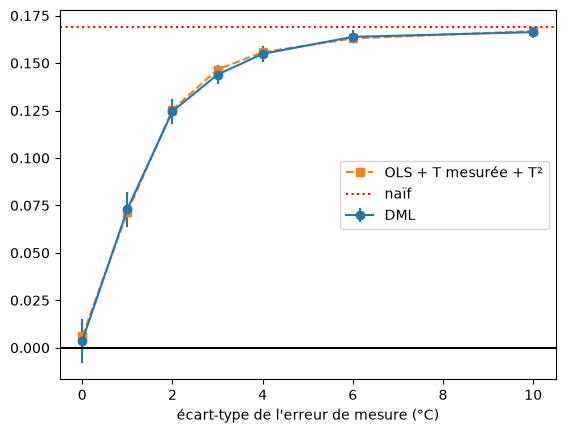

In [5]:
plt.errorbar(erreur.sigma, erreur.dml, yerr=[erreur.dml - erreur.dml_bas, erreur.dml_haut - erreur.dml], fmt="o-", label="DML")
plt.plot(erreur.sigma, erreur.ols_ctrl, "s--", label="OLS + T mesurée + T²")
plt.axhline(0, color="k")
plt.axhline(0.169, color="r", ls=":", label="naïf")
plt.xlabel("écart-type de l'erreur de mesure (°C)")
plt.legend()
plt.show()

## 2. Mauvais contrôle : le collider
On ajoute une variable causée **à la fois** par les glaces et les noyades : le nombre d'articles de presse
sur « l'été dangereux » (on parle des glaces qui se vendent et des noyades).
Glaces → presse ← noyades. Ce n'est pas un confondeur : il ne faut **pas** la contrôler.

In [6]:
rng = np.random.default_rng(456)
df["presse"] = 0.2 * df.glaces + 2 * df.noyades + rng.normal(0, 3, len(df))
df.corr().round(3)

,temperature,glaces,noyades,presse
temperature,1.000,0.974,0.897,0.927
glaces,0.974,1.000,0.887,0.930
noyades,0.897,0.887,1.000,0.964
presse,0.927,0.930,0.964,1.000


In [7]:
df["temperature2"] = df.temperature**2
print("OLS + T + T²          :", np.round(ols(df, ["glaces", "temperature", "temperature2"]), 4))
print("OLS + T + T² + presse :", np.round(ols(df, ["glaces", "temperature", "temperature2", "presse"]), 4))

OLS + T + T²          : [ 0.0061 -0.0051  0.0173]
OLS + T + T² + presse : [-0.0633 -0.0702 -0.0564]


In [8]:
m_bon = double_ml(df, ["temperature"])
m_collider = double_ml(df, ["temperature", "presse"])
print("DML (T)          :", m_bon.coef.round(4), m_bon.confint().round(4).values)
print("DML (T + presse) :", m_collider.coef.round(4), m_collider.confint().round(4).values)

DML (T)          : [0.0036] [[-0.0079  0.0151]]
DML (T + presse) : [-0.0625] [[-0.0695 -0.0555]]


Contrôler le collider crée un **biais négatif** alors que l'estimation était juste. Intuition : à nombre
d'articles de presse donné, si les glaces sont élevées, c'est qu'il y a eu moins de noyades pour « expliquer »
la presse → corrélation négative artificielle. Le DML n'y échappe pas : il fait confiance au choix des contrôles.

Est-ce que le résultat est sensible au poids de la presse ? Je fais varier les coefficients :

In [9]:
for a, b in [(0.2, 2), (0.5, 1), (0.1, 3), (1, 1)]:
    d = df.copy()
    d["presse"] = a * d.glaces + b * d.noyades + np.random.default_rng(456).normal(0, 3, len(d))
    print(a, b, np.round(ols(d, ["glaces", "temperature", "temperature2", "presse"])[0], 4))

0.2 2 -0.0633
0.5 1 -0.1496
0.1 3 -0.0267
1 1 -0.302


Le biais existe toujours, sa taille dépend de la structure. Je garde presse = 0.2·glaces + 2·noyades + N(0, 3).

Vérification avec effet vrai = 0.5 :

In [10]:
d5 = simuler(effet=0.5)
d5["temperature2"] = d5.temperature**2
d5["presse"] = 0.2 * d5.glaces + 2 * d5.noyades + np.random.default_rng(456).normal(0, 3, len(d5))
print(np.round(ols(d5, ["glaces", "temperature", "temperature2"]), 4))
print(np.round(ols(d5, ["glaces", "temperature", "temperature2", "presse"]), 4))

[0.5061 0.4949 0.5173]
[0.1164 0.1058 0.127 ]


Avec un effet vrai de 0.5, contrôler la presse fait tomber l'estimation à ~0.12 : le mauvais contrôle peut
effacer la plus grande partie d'un vrai effet.

## 3. Importance des variables (permutation)
Question : un modèle prédictif donne-t-il une « importance » élevée aux glaces alors qu'elles n'ont aucun effet ?

Premier essai : GB sur glaces + température exacte.

In [11]:
def importances(df, variables, seed=0):
    X_train, X_test, y_train, y_test = train_test_split(df[variables], df.noyades, test_size=0.3, random_state=seed)
    gb = GradientBoostingRegressor(random_state=seed).fit(X_train, y_train)
    imp = permutation_importance(gb, X_test, y_test, n_repeats=20, random_state=seed)
    return pd.Series(imp.importances_mean, index=variables)

importances(df, ["glaces", "temperature"])

glaces         0.033062
temperature    1.391610
dtype: float64

Avec la vraie température, les glaces n'apportent presque rien de plus → importance faible. Logique.
Mais en pratique on n'a souvent qu'une température imparfaite. Avec σ = 3 :

In [12]:
d = df.copy()
d["temp_mesuree"] = d.temperature + 3 * bruit
importances(d, ["glaces", "temp_mesuree"])

glaces          1.197442
temp_mesuree    0.037285
dtype: float64

Là, les glaces deviennent la variable la **plus importante** du modèle, alors que leur effet causal est nul :
elles servent de meilleur thermomètre que la température mesurée. L'importance mesure l'utilité pour **prédire**,
pas l'effet d'une intervention.

Comparaison avec un monde où l'effet vrai est 0.5 (même σ = 3) :

In [13]:
d5 = simuler(effet=0.5)
d5["temp_mesuree"] = d5.temperature + 3 * bruit
pd.DataFrame({"effet vrai = 0": importances(d, ["glaces", "temp_mesuree"]),
              "effet vrai = 0.5": importances(d5, ["glaces", "temp_mesuree"])}).round(3)

,effet vrai = 0,effet vrai = 0.5
glaces,1.197,1.831
temp_mesuree,0.037,0.004


L'importance des glaces est élevée dans les deux mondes : elle ne permet pas de distinguer un effet nul d'un effet réel.
Bonne figure : barres horizontales, deux panneaux (effet 0 / effet 0.5) ou barres groupées.

## Bilan pour `src/`
- `simulation.py` : `ajouter_temperature_mesuree(df, sigma, seed)` et `ajouter_presse(df, seed)`.
- `analyse.py` :
  - `effet_double_ml` prend une liste de contrôles en argument (par défaut `["temperature"]`) ;
  - `effet_ols` existe déjà ;
  - `biais_erreur_mesure(df, sigmas)` → tableau ;
  - `tableau_mauvais_controle(df)` → 4 lignes (OLS / DML, avec et sans presse) ;
  - `importances_permutation(df, variables)`.
- `graphiques.py` : biais selon σ, DAG avec collider, estimations avec et sans collider, importances.
- Le bruit de mesure est tiré une fois puis multiplié par σ, pour que la courbe soit lisse.